<a href="https://colab.research.google.com/github/Archin0/PCVK_Sem5/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 6 - Histogram, Histogram Equalization, Dithering

## Langkah 1 & 2: Persiapan Awal

In [2]:
# Langkah 1: Hubungkan ke Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Langkah 2: Impor semua library yang dibutuhkan
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import math
import os
import glob

Mounted at /content/drive


## Langkah 3: Membuat Histogram Citra Secara Manual

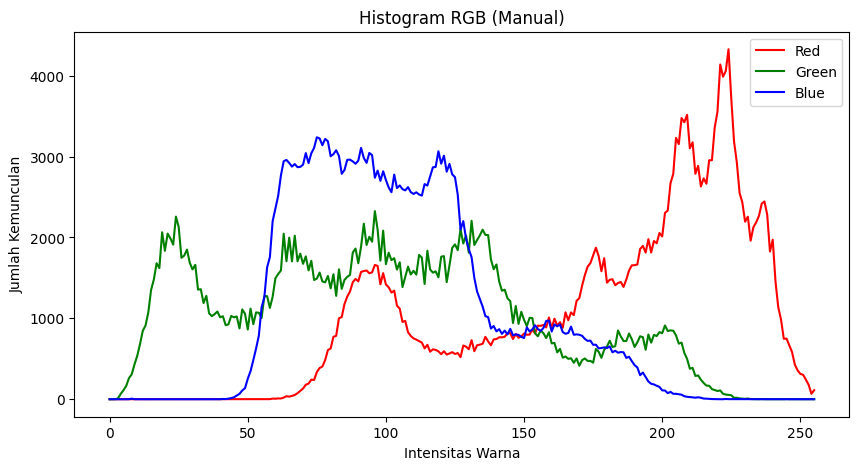

In [4]:
# Muat gambar dan konversi ke RGB
img_path = '/content/drive/MyDrive/PCVK/lenna.png'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Siapkan array kosong untuk menyimpan frekuensi setiap intensitas piksel (0-255)
r_hist = np.zeros(256, dtype=int)
g_hist = np.zeros(256, dtype=int)
b_hist = np.zeros(256, dtype=int)

# Hitung frekuensi untuk setiap channel
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r_hist[img_rgb[i, j, 0]] += 1
        g_hist[img_rgb[i, j, 1]] += 1
        b_hist[img_rgb[i, j, 2]] += 1

# Plot histogram
plt.figure(figsize=(10, 5))
plt.plot(r_hist, color='red', label='Red')
plt.plot(g_hist, color='green', label='Green')
plt.plot(b_hist, color='blue', label='Blue')
plt.title('Histogram RGB (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

## Langkah 4: Membuat Histogram dengan Library NumPy

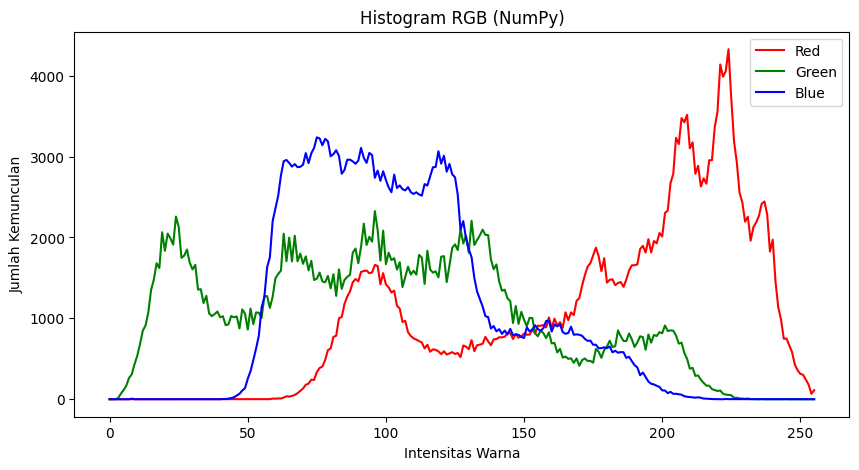

In [5]:
# Hitung histogram menggunakan NumPy
r_hist_np, _ = np.histogram(img_rgb[:,:,0].ravel(), bins=256, range=(0,256))
g_hist_np, _ = np.histogram(img_rgb[:,:,1].ravel(), bins=256, range=(0,256))
b_hist_np, _ = np.histogram(img_rgb[:,:,2].ravel(), bins=256, range=(0,256))

# Plot histogram
plt.figure(figsize=(10, 5))
plt.plot(r_hist_np, color='red', label='Red')
plt.plot(g_hist_np, color='green', label='Green')
plt.plot(b_hist_np, color='blue', label='Blue')
plt.title('Histogram RGB (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

Jawaban Perbandingan: Ya, output yang muncul sama. Hasil perhitungan manual dan menggunakan np.histogram menghasilkan grafik histogram yang identik. Perbedaannya adalah kode yang menggunakan NumPy jauh lebih singkat dan efisien.

## Langkah 5: Histogram Equalization Manual

Gambar Low Contrast Berhasil Dibuat!


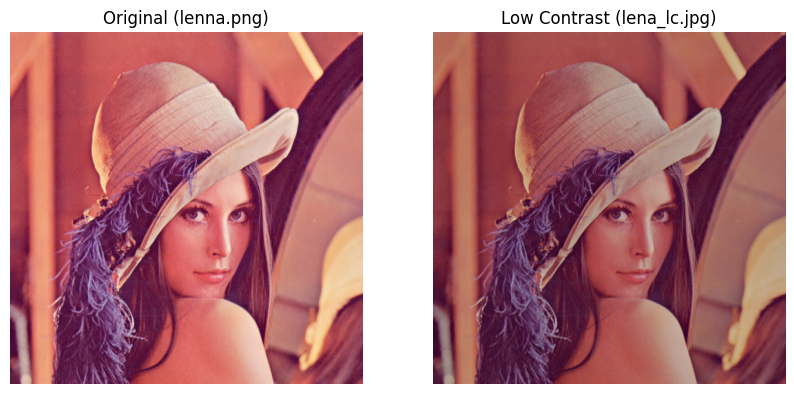

In [20]:
# Muat Gambar Asli
path_lena = '/content/drive/MyDrive/PCVK/lenna.png'
img_original = cv2.imread(path_lena)

if img_original is None:
    print(f"Error: Gambar tidak ditemukan di path: {path_lena}")
else:
    # Buat Versi Low Contrast
    # Alpha (kontras) < 1 untuk mengurangi kontras
    # Beta (kecerahan) disesuaikan agar gambar tidak terlalu gelap
    alpha = 0.8  # Mengurangi kontras sebesar 50%
    beta = 0    # Menambah kecerahan

    img_lc = cv2.convertScaleAbs(img_original, alpha=alpha, beta=beta)

    # (Opsional) Simpan gambar low contrast agar bisa digunakan nanti
    path_lc_save = '/content/drive/MyDrive/PCVK/lena_lc.jpg'
    cv2.imwrite(path_lc_save, img_lc)

    # Tampilkan perbandingan
    print("Gambar Low Contrast Berhasil Dibuat!")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
    plt.title('Original (lenna.png)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_lc, cv2.COLOR_BGR2RGB))
    plt.title('Low Contrast (lena_lc.jpg)')
    plt.axis('off')

    plt.show()

/tmp/ipython-input-4276745028.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_lc_gray.flatten(), 256, [0,256], color = 'gray')
/tmp/ipython-input-4276745028.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_he_manual.flatten(), 256, [0,256], color = 'gray')


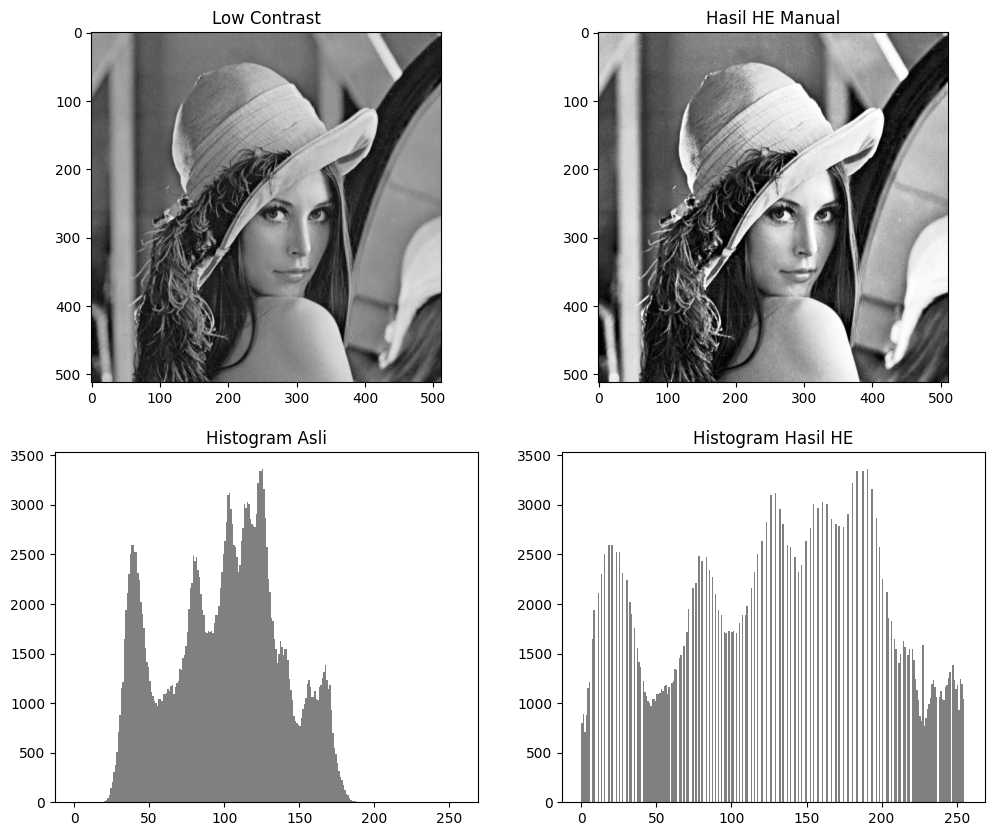

In [21]:
# Muat gambar low contrast yang baru dibuat dan ubah ke grayscale
path_lc = '/content/drive/MyDrive/PCVK/lena_lc.jpg'
img_lc_gray = cv2.imread(path_lc, cv2.IMREAD_GRAYSCALE)

# 1. Hitung histogram
hist, bins = np.histogram(img_lc_gray.flatten(), 256, [0,256])

# 2. Hitung Cumulative Distribution Function (CDF)
cdf = hist.cumsum()

# 3. Buat lookup table (LUT) untuk pemetaan nilai piksel baru
# Rumus normalisasi CDF
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

# 4. Terapkan HE pada gambar
img_he_manual = cdf_final[img_lc_gray]

# Tampilkan gambar dan histogramnya
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(img_lc_gray, cmap='gray')
axs[0, 0].set_title('Low Contrast')
axs[0, 1].imshow(img_he_manual, cmap='gray')
axs[0, 1].set_title('Hasil HE Manual')

axs[1, 0].hist(img_lc_gray.flatten(), 256, [0,256], color = 'gray')
axs[1, 0].set_title('Histogram Asli')

axs[1, 1].hist(img_he_manual.flatten(), 256, [0,256], color = 'gray')
axs[1, 1].set_title('Histogram Hasil HE')
plt.show()

## Langkah 6: Histogram Equalization dengan Library CV2

/tmp/ipython-input-3153947784.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_he_manual.flatten(), 256, [0,256], color = 'gray')
/tmp/ipython-input-3153947784.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_he_cv2.flatten(), 256, [0,256], color = 'gray')


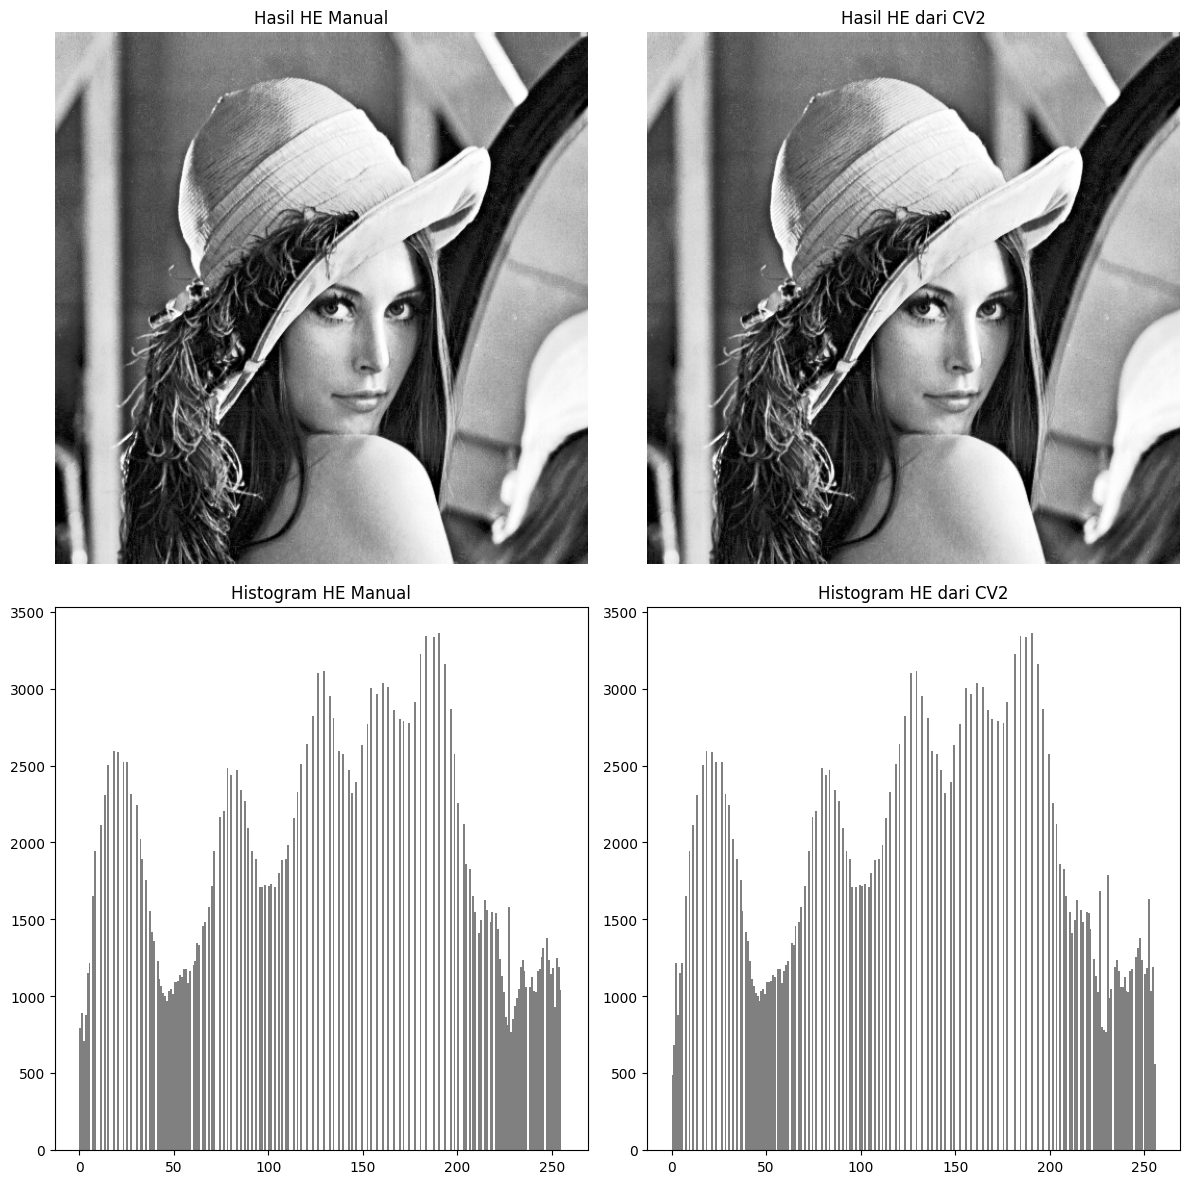

In [27]:
# --- Kode dari Langkah 5 (HE Manual) ---
hist, bins = np.histogram(img_lc_gray.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
img_he_manual = cdf_final[img_lc_gray]
# --- Akhir Kode Langkah 5 ---

# Terapkan HE menggunakan OpenCV
img_he_cv2 = cv2.equalizeHist(img_lc_gray)

# --- Visualisasi dengan Histogram ---
plt.figure(figsize=(12, 12))

# Hasil HE Manual
plt.subplot(2, 2, 1)
plt.imshow(img_he_manual, cmap='gray')
plt.title('Hasil HE Manual')
plt.axis('off')

# Histogram HE Manual
plt.subplot(2, 2, 3)
plt.hist(img_he_manual.flatten(), 256, [0,256], color = 'gray')
plt.title('Histogram HE Manual')

# Hasil HE CV2
plt.subplot(2, 2, 2)
plt.imshow(img_he_cv2, cmap='gray')
plt.title('Hasil HE dari CV2')
plt.axis('off')

# Histogram HE CV2
plt.subplot(2, 2, 4)
plt.hist(img_he_cv2.flatten(), 256, [0,256], color = 'gray')
plt.title('Histogram HE dari CV2')

plt.tight_layout()
plt.show()

Jawaban Perbandingan: Ya, output yang muncul sama. Hasil antara implementasi manual dan fungsi cv2.equalizeHist sangat mirip, keduanya berhasil "meratakan" sebaran intensitas warna dan meningkatkan kontras gambar secara signifikan.

## Langkah 7: Pemetaan Warna (8 Warna) pada Gambar Asli

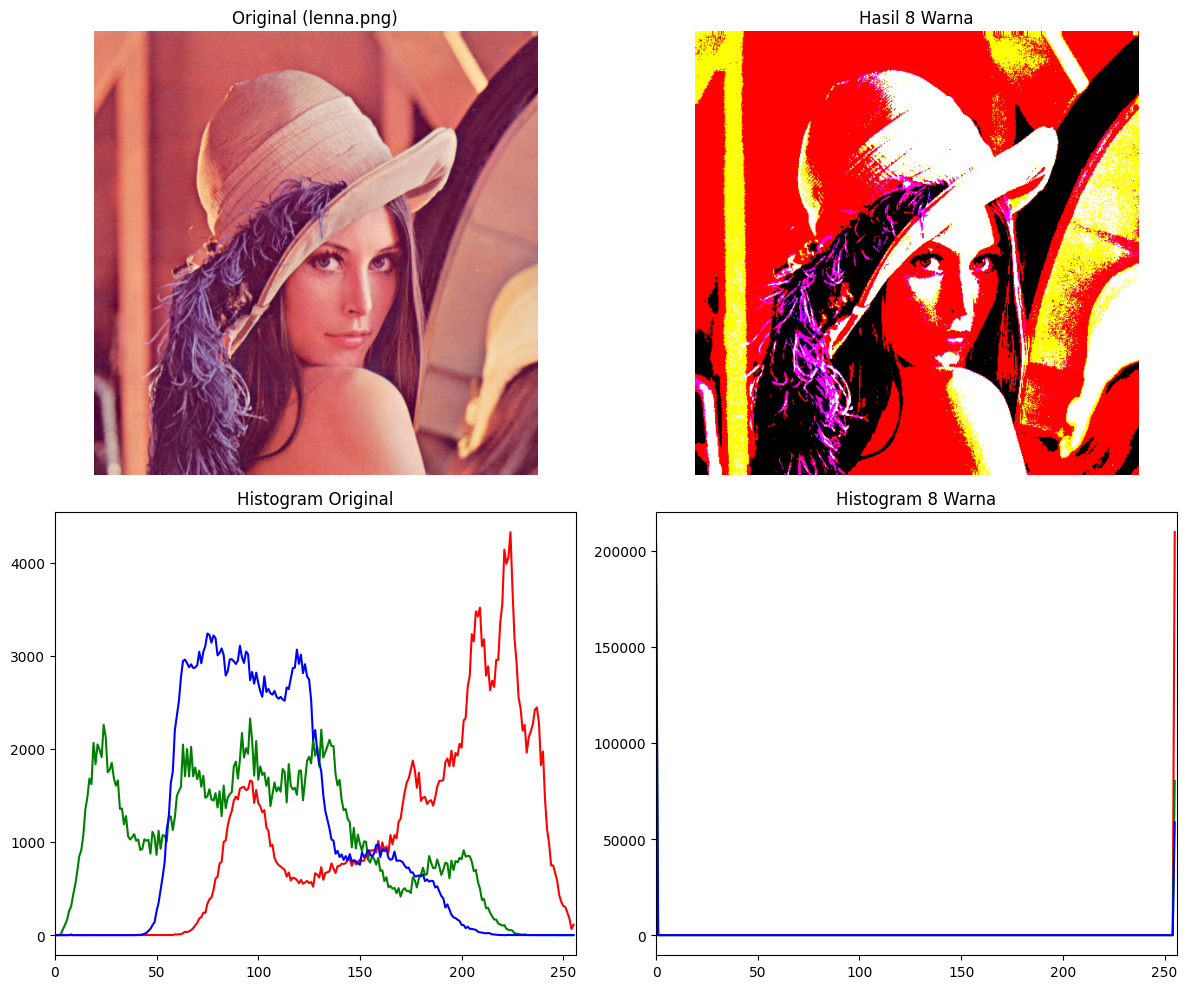

In [31]:
img_original_rgb = cv2.cvtColor(cv2.imread(path_lena), cv2.COLOR_BGR2RGB)

# Definisikan palet 8 warna
palette = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255],
                    [255, 255, 0], [0, 255, 255], [255, 0, 255], [255, 255, 255]])

# Proses pemetaan warna (kuantisasi)
new_img = np.zeros_like(img_original_rgb)
for i in range(img_original_rgb.shape[0]):
    for j in range(img_original_rgb.shape[1]):
        distances = np.sum((palette - img_original_rgb[i, j])**2, axis=1)
        new_img[i, j] = palette[np.argmin(distances)]

# --- Visualisasi dengan Histogram ---
plt.figure(figsize=(12, 10))

# Gambar Asli
plt.subplot(2, 2, 1)
plt.imshow(img_original_rgb)
plt.title('Original (lenna.png)')
plt.axis('off')

# Histogram Asli
plt.subplot(2, 2, 3)
colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    hist_original = cv2.calcHist([img_original_rgb], [i], None, [256], [0, 256])
    plt.plot(hist_original, color=color)
plt.title('Histogram Original')
plt.xlim([0, 256])

# Gambar 8 Warna
plt.subplot(2, 2, 2)
plt.imshow(new_img)
plt.title('Hasil 8 Warna')
plt.axis('off')

# Histogram 8 Warna
plt.subplot(2, 2, 4)
for i, color in enumerate(colors):
    hist_8_color = cv2.calcHist([new_img], [i], None, [256], [0, 256])
    plt.plot(hist_8_color, color=color)
plt.title('Histogram 8 Warna')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## Langkah 8: Dithering Floyd and Steinberg pada Gambar Asli

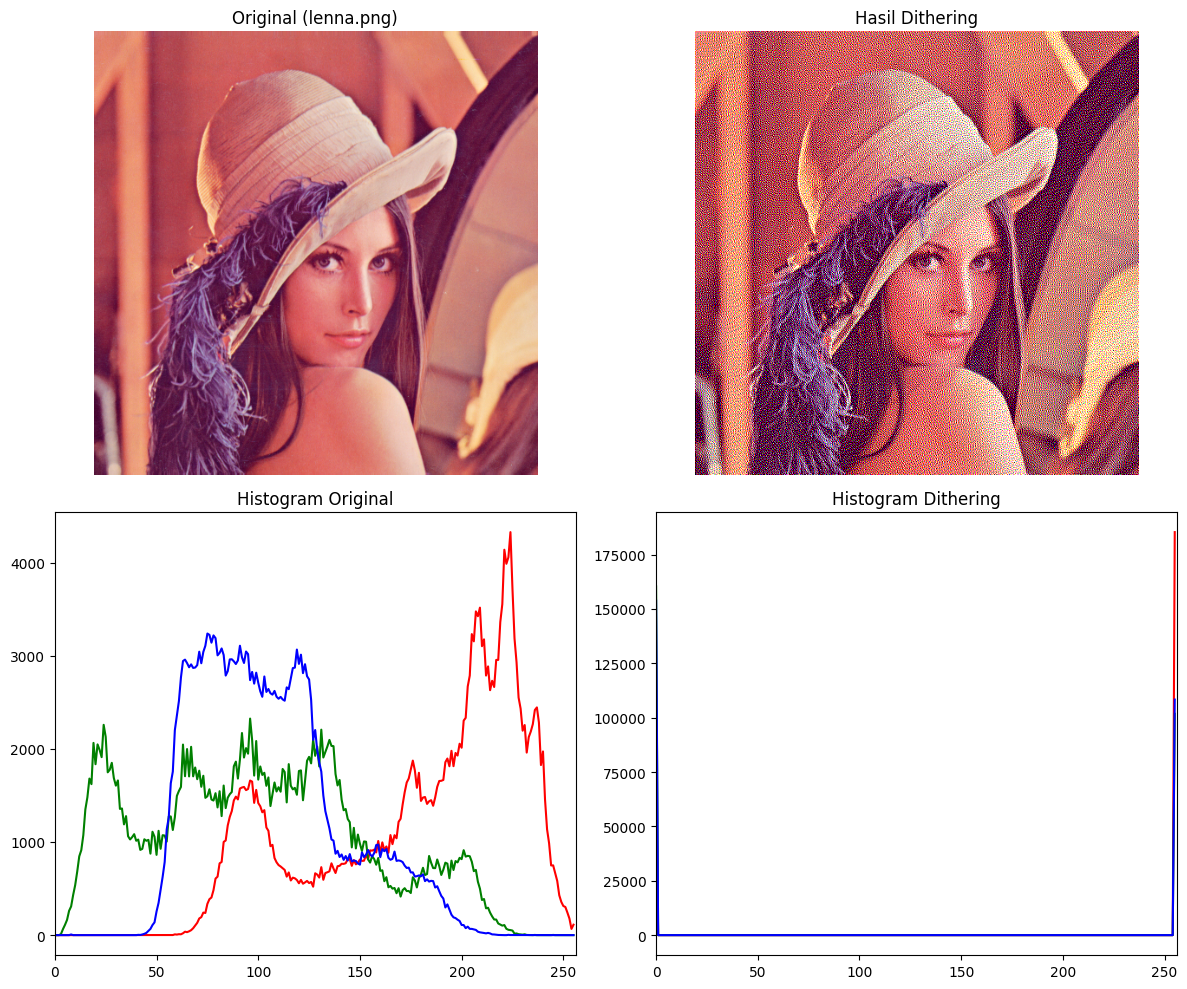

In [30]:
# Muat gambar asli dan konversi ke float
img_dither_original = cv2.cvtColor(cv2.imread(path_lena), cv2.COLOR_BGR2RGB).astype(float)
h, w, _ = img_dither_original.shape

def find_closest_color(pixel, color_palette):
    distances = np.sum((color_palette - pixel)**2, axis=1)
    return color_palette[np.argmin(distances)]

# Terapkan Dithering
for y in range(h):
    for x in range(w):
        old_pixel = img_dither_original[y, x].copy()
        new_pixel = find_closest_color(old_pixel, palette)
        img_dither_original[y, x] = new_pixel
        quant_error = old_pixel - new_pixel

        if x + 1 < w: img_dither_original[y, x + 1] += quant_error * 7 / 16
        if x - 1 >= 0 and y + 1 < h: img_dither_original[y + 1, x - 1] += quant_error * 3 / 16
        if y + 1 < h: img_dither_original[y + 1, x] += quant_error * 5 / 16
        if x + 1 < w and y + 1 < h: img_dither_original[y + 1, x + 1] += quant_error * 1 / 16

img_dither_result = np.clip(img_dither_original, 0, 255).astype(np.uint8)

# --- Visualisasi dengan Histogram ---
plt.figure(figsize=(12, 10))

# Gambar Asli
plt.subplot(2, 2, 1)
plt.imshow(img_original_rgb)
plt.title('Original (lenna.png)')
plt.axis('off')

# Histogram Asli
plt.subplot(2, 2, 3)
for i, color in enumerate(colors):
    hist_original = cv2.calcHist([img_original_rgb], [i], None, [256], [0, 256])
    plt.plot(hist_original, color=color)
plt.title('Histogram Original')
plt.xlim([0, 256])

# Gambar Dithering
plt.subplot(2, 2, 2)
plt.imshow(img_dither_result)
plt.title('Hasil Dithering')
plt.axis('off')

# Histogram Dithering
plt.subplot(2, 2, 4)
for i, color in enumerate(colors):
    hist_dither = cv2.calcHist([img_dither_result], [i], None, [256], [0, 256])
    plt.plot(hist_dither, color=color)
plt.title('Histogram Dithering')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## Langkah 9: Grayscale HE + Dithering pada Gambar Low Contrast

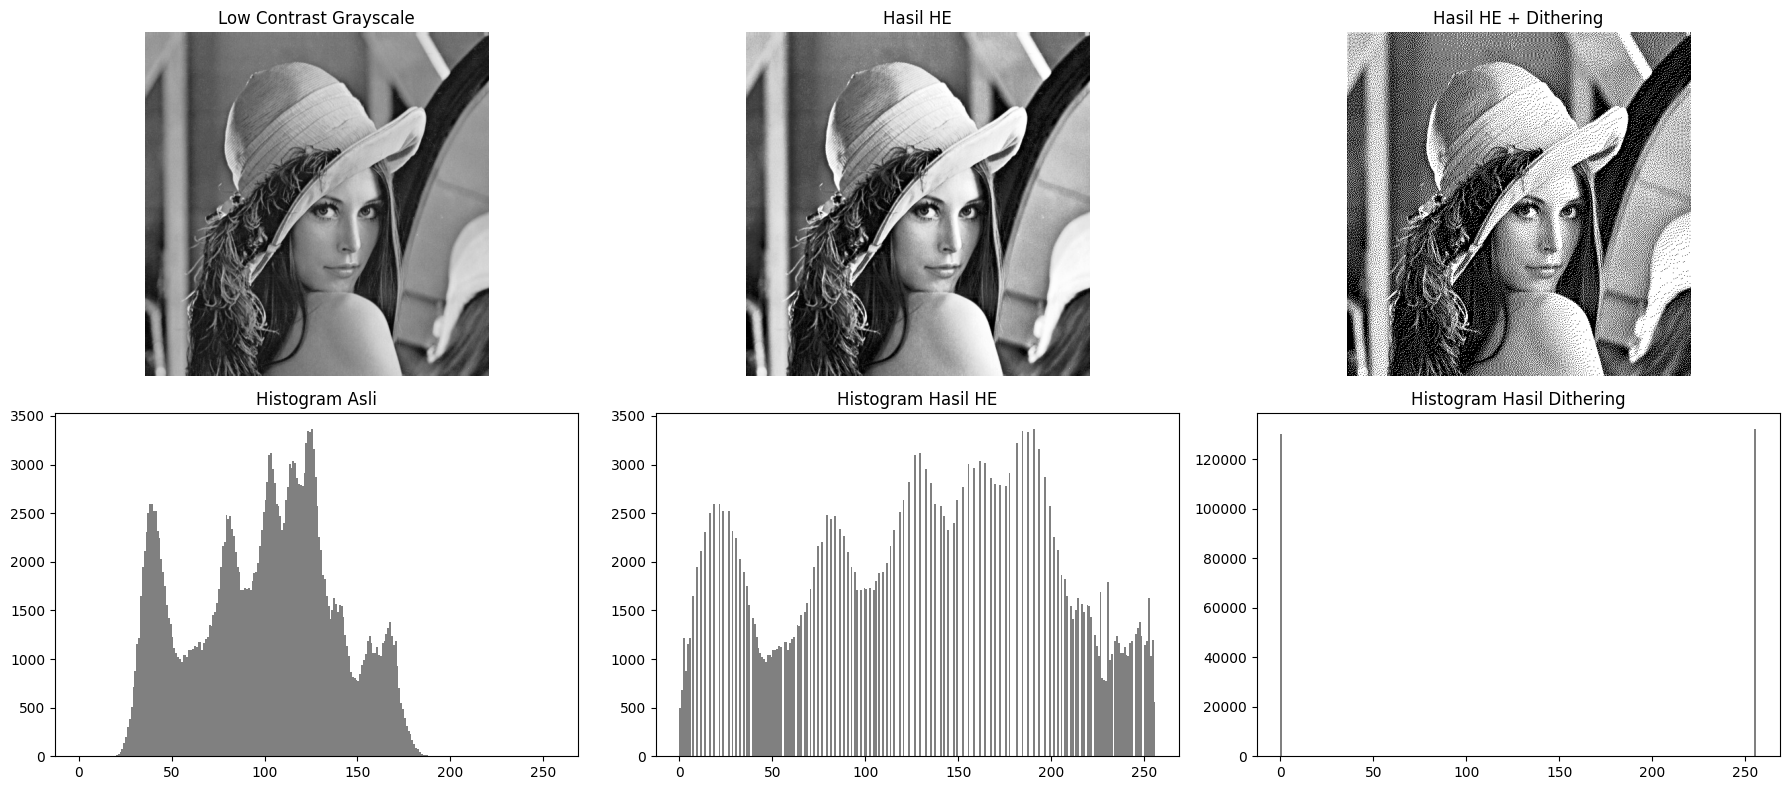

In [33]:
# 1. Muat gambar low contrast grayscale
img_lc_gray = cv2.imread(path_lc, cv2.IMREAD_GRAYSCALE)

# 2. Terapkan Histogram Equalization
img_he_gray = cv2.equalizeHist(img_lc_gray)

# 3. Terapkan Dithering pada hasil HE (palet grayscale: hitam & putih)
gray_palette = np.array([[0], [255]])
img_dither_gray = img_he_gray.copy().astype(float)
h, w = img_dither_gray.shape

for y in range(h):
    for x in range(w):
        old_pixel = img_dither_gray[y, x]
        new_pixel = gray_palette[np.argmin(np.abs(gray_palette - old_pixel))][0] # Extract scalar
        img_dither_gray[y, x] = new_pixel
        quant_error = old_pixel - new_pixel

        if x + 1 < w: img_dither_gray[y, x + 1] += quant_error * 7 / 16
        if x - 1 >= 0 and y + 1 < h: img_dither_gray[y + 1, x - 1] += quant_error * 3 / 16
        if y + 1 < h: img_dither_gray[y + 1, x] += quant_error * 5 / 16
        if x + 1 < w and y + 1 < h: img_dither_gray[y + 1, x + 1] += quant_error * 1 / 16

img_dither_gray_result = np.clip(img_dither_gray, 0, 255).astype(np.uint8)

# --- Visualisasi dengan Histogram ---
plt.figure(figsize=(18, 8))

# Gambar Low Contrast Grayscale
plt.subplot(2, 3, 1)
plt.imshow(img_lc_gray, cmap='gray')
plt.title('Low Contrast Grayscale')
plt.axis('off')

# Histogramnya
plt.subplot(2, 3, 4)
plt.hist(img_lc_gray.flatten(), bins=256, range=[0,256], color = 'gray') # Use keyword argument for range
plt.title('Histogram Asli')

# Gambar Hasil HE
plt.subplot(2, 3, 2)
plt.imshow(img_he_gray, cmap='gray')
plt.title('Hasil HE')
plt.axis('off')

# Histogramnya
plt.subplot(2, 3, 5)
plt.hist(img_he_gray.flatten(), bins=256, range=[0,256], color = 'gray') # Use keyword argument for range
plt.title('Histogram Hasil HE')

# Gambar Hasil Dithering
plt.subplot(2, 3, 3)
plt.imshow(img_dither_gray_result, cmap='gray')
plt.title('Hasil HE + Dithering')
plt.axis('off')

# Histogramnya
plt.subplot(2, 3, 6)
plt.hist(img_dither_gray_result.flatten(), bins=256, range=[0,256], color = 'gray') # Use keyword argument for range
plt.title('Histogram Hasil Dithering')

plt.tight_layout()
plt.show()